# Results Dashboard

Visualizes experiment results from the centralized `results/experiment_results.csv`.

This CSV is automatically populated by `graphium-train` after each run.
Each row = one training run with metadata and all test metrics.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebook_utils import (
    ADMET_TASK_ORDER, TASK_CATEGORY, TASK_METRICS, TDC_SOTA,
    MODEL_REGISTRY, FAMILY_COLORS, FAMILY_HATCHES,
    infer_model_name, infer_model_family,
    load_results, load_tdc_top10, build_method_colors,
    normalize_scores, count_best_among_methods, find_metric_column, get_sota,
)

# === Config: select which model(s) to show ===
MODELS_TO_SHOW = [
    'gpspp_800M',
    'pairformer_17M',
    'pairmixer_10M',
]

df, admet_df = load_results(models_to_show=MODELS_TO_SHOW)
print(f"Loaded {len(df)} rows, {len(admet_df)} ADMET rows")
print(f"Models: {admet_df['model_name'].value_counts().to_dict()}")

# TDC top-10 data
TDC_TOP10_ALL, TDC_TOP10_AVG, TDC_TOP10_MEDIAN = load_tdc_top10()

# Method colors (dynamic from data)
METHOD_COLORS = build_method_colors(admet_df)

# Default variant per family (used in the main per-task chart)
DEFAULT_VARIANT = {
    'GPS++':      'gpspp_800M',
    'Pairformer': 'pairformer_17M',
    'PairMixer':  'pairmixer_10M',
}

print(f"Methods: {sorted(admet_df['method'].unique())}")

Loaded 1279 rows from ../results/experiment_results.csv
After filtering to ['gpspp_800M', 'pairformer_17M', 'pairmixer_10M']: 695 rows
  model_name counts: {'gpspp_800M': 659, 'pairmixer_10M': 31, 'pairformer_17M': 5}


## 1. Overview: runs by model and task

In [2]:
print("Runs by model:")
print(df['model_name'].value_counts().to_string())
print()
print("Runs by task:")
print(df['task'].value_counts().to_string())
print()
df['is_finetuning'] = df['is_finetuning'].fillna(False).astype(bool)
print(f"Finetuned: {df['is_finetuning'].sum()} / Scratch: {(~df['is_finetuning']).sum()}")

Runs by model:
model_name
gpspp_800M        659
pairmixer_10M      31
pairformer_17M      5

Runs by task:
task
caco2_wang                        94
multitask                         67
solubility_aqsoldb                60
half_life_obach                   40
clearance_hepatocyte_az           40
clearance_microsome_az            39
ld50_zhu                          39
lipophilicity_astrazeneca         28
pgp_broccatelli                   25
hia_hou                           24
bioavailability_ma                23
bbb_martins                       21
ppbr_az                           20
vdss_lombardo                     20
cyp2d6_veith                      18
herg                              18
cyp3a4_substrate_carbonmangels    17
cyp2c9_substrate_carbonmangels    17
cyp2c9_veith                      17
cyp3a4_veith                      17
cyp2d6_substrate_carbonmangels    17
ames                              17
dili                              17

Finetuned: 598 / Scratch: 97


## 2. Extract primary metric per task

Each ADMET task has a primary metric. We extract the test metric column for each task.

In [3]:
# Primary metrics already extracted by load_results() above.
# Report extraction stats.
print(f"Tasks with extracted metrics: {df['primary_metric'].notna().sum()} / {len(df)}")

_failed = df[df['primary_metric'].isna()]
if len(_failed) > 0:
    print(f"\nFailed metric extraction ({len(_failed)} rows):")
    for task, count in _failed['task'].value_counts().items():
        if task not in TASK_METRICS:
            reason = "task not in TASK_METRICS (not an ADMET single-task)"
        else:
            metric_name, _ = TASK_METRICS[task]
            col = find_metric_column(df, task, metric_name)
            reason = f"metric column not found for '{metric_name}'" if col is None else "metric value is NaN"
        print(f"  - task='{task}' x {count} rows  ({reason})")

Tasks with extracted metrics: 627 / 695

Failed metric extraction (68 rows):
  - task='multitask' × 67 rows  (task not in TASK_METRICS (not an ADMET single-task))
  - task='pgp_broccatelli' × 1 rows  (metric value is NaN)


## 3. Dataset type ablation

Compare downstream ADMET performance across pre-training datasets.

In [4]:
# Data pipeline (parse_pretrain_dataset, build_method_label, etc.) is handled
# by load_results() in cell 1. admet_df is ready to use.

print(f"ADMET results: {len(admet_df)} rows")
print(f"Methods: {sorted(admet_df['method'].unique())}")
print(f"Method colors: {METHOD_COLORS}")

# --- Compute global best (across all architectures) per task ---
global_best_per_task = {}  # task -> (model_name, method)
if len(admet_df) > 0 and admet_df['primary_metric'].notna().any():
    for task in ADMET_TASK_ORDER:
        task_rows = admet_df[admet_df['task'] == task].dropna(subset=['primary_metric'])
        if len(task_rows) == 0:
            continue
        direction = TASK_METRICS.get(task, (None, 'higher'))[1]
        if direction == 'lower':
            best_row = task_rows.loc[task_rows['primary_metric'].idxmin()]
        else:
            best_row = task_rows.loc[task_rows['primary_metric'].idxmax()]
        global_best_per_task[task] = (best_row['model_name'], best_row['method'])

# --- Display one table per architecture ---
if len(admet_df) > 0 and admet_df['primary_metric'].notna().any():
    for model_name in MODELS_TO_SHOW:
        model_df = admet_df[admet_df['model_name'] == model_name]

        if len(model_df) == 0 or model_df['primary_metric'].isna().all():
            # No data at all — show empty table with all tasks
            pivot = pd.DataFrame(index=ADMET_TASK_ORDER, columns=['(no results)'])
            pivot['(no results)'] = np.nan
        else:
            pivot = model_df.pivot_table(
                index='task', columns='method', values='primary_metric', aggfunc='mean'
            )
            method_order = ['Scratch'] + sorted([c for c in pivot.columns if c != 'Scratch'])
            method_order += [c for c in pivot.columns if c not in method_order]
            pivot = pivot[[c for c in method_order if c in pivot.columns]]

        # Reindex to always show all 22 ADMET tasks (NaN for missing)
        pivot = pivot.reindex(ADMET_TASK_ORDER)

        row_labels = []
        for task in pivot.index:
            metric_name, direction = TASK_METRICS.get(task, ('?', 'higher'))
            arrow = '\u2191' if direction == 'higher' else '\u2193'
            row_labels.append(f'{task}  ({metric_name} {arrow})')

        # Find best column per row within this architecture
        arch_best_per_row = {}
        for task in pivot.index:
            direction = TASK_METRICS.get(task, (None, 'higher'))[1]
            row_vals = pivot.loc[task].dropna()
            if len(row_vals) > 0:
                best_col = row_vals.idxmin() if direction == 'lower' else row_vals.idxmax()
                arch_best_per_row[task] = best_col

        numeric_pivot = pivot.copy()

        # Insert TDC SOTA column on the left
        sota_col = []
        for task in pivot.index:
            if task in TDC_SOTA:
                mean, std, _ = TDC_SOTA[task]
                sota_col.append(f'{mean:.3f} \u00b1 {std:.3f}')
            else:
                sota_col.append('')
        pivot.insert(0, 'TDC SOTA', sota_col)

        # Compute category boundaries
        category_boundaries = set()
        prev_cat = None
        for i, task in enumerate(pivot.index):
            cat = TASK_CATEGORY.get(task)
            if prev_cat is not None and cat != prev_cat:
                category_boundaries.add(i)
            prev_cat = cat

        display_pivot = pivot.copy()
        display_pivot.index = row_labels

        # Styling: bold = best within arch, blue+underline = best across all archs
        def make_highlight(arch_best, global_best, cur_model, dp, pv):
            def highlight(row):
                task = pv.index[dp.index.get_loc(row.name)]
                styles = [''] * len(row)
                cols = list(dp.columns)
                metric_info = TASK_METRICS.get(task, (None, None))
                direction = metric_info[1]
                sota_info = TDC_SOTA.get(task)

                for j, col in enumerate(cols):
                    if col == 'TDC SOTA':
                        continue
                    try:
                        val = float(row.iloc[j])
                    except (ValueError, TypeError):
                        continue
                    if pd.isna(val):
                        continue

                    # Check if value exceeds SOTA (within std)
                    exceeds_sota = False
                    if sota_info is not None and direction is not None:
                        sota_mean, sota_std, _ = sota_info
                        if direction == 'higher' and val >= sota_mean - sota_std:
                            exceeds_sota = True
                        elif direction == 'lower' and val <= sota_mean + sota_std:
                            exceeds_sota = True

                    if exceeds_sota:
                        styles[j] = 'font-weight: bold; color: #cc0000'

                # Architecture best: bold (overrides red if not exceeding SOTA)
                if task in arch_best:
                    j = cols.index(arch_best[task])
                    if 'color: #cc0000' not in styles[j]:
                        styles[j] = 'font-weight: bold'

                # Global best: blue + underline (overrides arch-best, but not red)
                if task in global_best:
                    g_model, g_method = global_best[task]
                    if g_model == cur_model and g_method in cols:
                        k = cols.index(g_method)
                        if 'color: #cc0000' not in styles[k]:
                            styles[k] = 'font-weight: bold; color: #1a5fb4; text-decoration: underline'

                return styles
            return highlight

        def make_category_borders(boundaries, dp):
            def category_borders(row):
                idx = dp.index.get_loc(row.name)
                if idx in boundaries:
                    return ['border-top: 3px solid black'] * len(row)
                return [''] * len(row)
            return category_borders

        def sota_style(col):
            if col.name == 'TDC SOTA':
                return ['background-color: #f0f0f0; color: #555; font-size: 0.9em'] * len(col)
            return [''] * len(col)

        styled = (
            display_pivot.style
            .format(precision=4, na_rep='',
                    subset=[c for c in display_pivot.columns if c != 'TDC SOTA'])
            .apply(make_highlight(arch_best_per_row, global_best_per_task,
                                  model_name, display_pivot, pivot), axis=1)
            .apply(make_category_borders(category_boundaries, display_pivot), axis=1)
            .apply(sota_style, axis=0)
            .set_caption(f'{model_name} — ADMET Performance (TDC SOTA on left for reference)')
            .set_table_styles([
                {'selector': 'th', 'props': [('font-weight', 'bold')]},
                {'selector': 'td', 'props': [('text-align', 'center')]},
            ])
        )

        print(f"\n{'='*60}")
        print(f"  {model_name}")
        print(f"{'='*60}")
        print("Bold = best within architecture | Blue + underline = best across all architectures")
        display(styled)

        # Count tasks where each method is the best
        best_counts = count_best_among_methods(numeric_pivot, list(numeric_pivot.columns), TASK_METRICS)
        if best_counts:
            print(f"\nTasks where each method is best ({model_name}):")
            for method, (wins, total) in best_counts.items():
                print(f"  {method}: {wins}/{total}")

    # --- Cross-architecture summary ---
    combined_pivot = admet_df.pivot_table(
        index='task', columns=['model_name', 'method'],
        values='primary_metric', aggfunc='mean'
    )
    combined_pivot = combined_pivot.loc[[t for t in ADMET_TASK_ORDER if t in combined_pivot.index]]
    all_cols = list(combined_pivot.columns)
    best_counts = count_best_among_methods(combined_pivot, all_cols, TASK_METRICS)

    print(f"\n{'='*60}")
    print("  Cross-architecture summary: tasks where each (model, method) is best")
    print(f"{'='*60}")
    for col, (wins, total) in best_counts.items():
        model, method = col
        print(f"  {model} / {method}: {wins}/{total}")
else:
    print("No ADMET results found yet. Run experiments first.")

After dedup to latest run per (task, model_name, method): 318 rows
Models in data: {'gpspp_800M': 289, 'pairmixer_10M': 24, 'pairformer_17M': 5}
Method color assignments: {'Scratch': '#999999', 'dti': '#466eff', 'largemix': '#64B478', 'largemix_dti': '#EB423D', 'rxrx3': '#FF883D', 'rxrx3_dti': '#9B59B6', 'toymix': '#17becf', 'toymix_bbbc047': '#bcbd22', 'toymix_dti': '#e377c2', 'toymix_dti_esmc_v2': '#d62728', 'toymix_dti_filtered': '#8c564b', 'toymix_dti_v2': '#466eff', 'toymix_lpm24': '#64B478', 'toymix_rxrx3': '#EB423D', 'toymix_rxrx3_dti': '#FF883D'}

  gpspp_800M
Bold = best within architecture | Blue + underline = best across all architectures


method,TDC SOTA,Scratch,dti,largemix,largemix_dti,rxrx3,rxrx3_dti,toymix,toymix_bbbc047,toymix_dti,toymix_dti_esmc_v2,toymix_dti_filtered,toymix_dti_v2,toymix_lpm24,toymix_rxrx3,toymix_rxrx3_dti
caco2_wang (mae ↓),0.256 ± 0.006,0.5648,5.3263,0.4899,0.5056,1.2462,0.7230,5.2247,0.4873,0.4466,0.4917,0.5672,0.5379,0.5891,0.5438,0.5284
hia_hou (auroc ↑),0.993 ± 0.005,0.5000,0.5000,0.9014,0.6840,0.4988,0.7267,0.8333,0.9150,0.8712,0.9465,0.9506,0.8317,0.7700,0.6066,0.7313
pgp_broccatelli (auroc ↑),0.938 ± 0.002,0.8214,0.5000,0.8890,0.8134,0.4373,0.8194,0.8155,0.7902,0.8919,0.8684,0.7996,0.7353,0.7792,0.8305,0.7345
bioavailability_ma (auroc ↑),0.938 ± 0.002,0.5000,0.5000,0.5271,0.5316,0.5037,0.5786,0.6275,0.4613,0.5632,0.5614,0.6345,0.5735,0.6209,0.5449,0.5883
lipophilicity_astrazeneca (mae ↓),0.456 ± 0.008,0.9721,2.3666,0.7559,0.8889,0.9677,0.9647,0.9724,0.8961,0.8436,0.9017,0.9145,0.9381,0.9462,0.9782,0.9174
solubility_aqsoldb (mae ↓),0.741 ± 0.013,1.0424,3.4085,1.0715,1.5022,1.8897,1.4641,1.4957,1.4241,1.2442,1.3547,1.3231,1.4160,1.4697,1.2084,1.2582
bbb_martins (auroc ↑),0.924 ± 0.003,0.7324,0.5000,0.8485,0.7972,0.5569,0.7043,0.3988,0.7403,0.8080,0.7502,0.8086,0.7837,0.7229,0.7836,0.7282
ppbr_az (mae ↓),7.440 ± 0.024,81.4208,88.6763,8.5499,9.4128,17.4642,15.7294,13.3702,9.6523,8.8819,8.9347,9.5635,9.8418,,9.6962,9.6880
vdss_lombardo (spearman ↑),0.713 ± 0.007,0.4539,0.0000,0.4888,0.4398,0.0541,0.2888,0.2426,0.5075,0.5988,0.5919,0.5317,0.4528,,0.3875,0.4868
cyp2d6_veith (auprc ↑),0.790 ± 0.001,0.1766,0.1687,0.6463,0.4494,0.1488,0.4021,0.1469,0.4283,0.5229,,0.3949,,,0.4564,0.4094



Tasks where each method is best (gpspp_800M):
  Scratch: 2/22
  dti: 0/22
  largemix: 10/22
  largemix_dti: 0/22
  rxrx3: 0/22
  rxrx3_dti: 0/22
  toymix: 1/22
  toymix_bbbc047: 0/22
  toymix_dti: 6/22
  toymix_dti_esmc_v2: 0/22
  toymix_dti_filtered: 2/22
  toymix_dti_v2: 0/22
  toymix_lpm24: 0/22
  toymix_rxrx3: 0/22
  toymix_rxrx3_dti: 1/22

  pairformer_17M
Bold = best within architecture | Blue + underline = best across all architectures


method,TDC SOTA,Scratch
caco2_wang (mae ↓),0.256 ± 0.006,1.0859
hia_hou (auroc ↑),0.993 ± 0.005,
pgp_broccatelli (auroc ↑),0.938 ± 0.002,0.8511
bioavailability_ma (auroc ↑),0.938 ± 0.002,
lipophilicity_astrazeneca (mae ↓),0.456 ± 0.008,
solubility_aqsoldb (mae ↓),0.741 ± 0.013,0.9141
bbb_martins (auroc ↑),0.924 ± 0.003,
ppbr_az (mae ↓),7.440 ± 0.024,
vdss_lombardo (spearman ↑),0.713 ± 0.007,
cyp2d6_veith (auprc ↑),0.790 ± 0.001,



Tasks where each method is best (pairformer_17M):
  Scratch: 5/5

  pairmixer_10M
Bold = best within architecture | Blue + underline = best across all architectures


method,TDC SOTA,Scratch,toymix,toymix_dti
caco2_wang (mae ↓),0.256 ± 0.006,,,5.2500
hia_hou (auroc ↑),0.993 ± 0.005,,,0.5000
pgp_broccatelli (auroc ↑),0.938 ± 0.002,,,0.5000
bioavailability_ma (auroc ↑),0.938 ± 0.002,,,0.5000
lipophilicity_astrazeneca (mae ↓),0.456 ± 0.008,1.0625,0.9492,1.9922
solubility_aqsoldb (mae ↓),0.741 ± 0.013,,,2.7031
bbb_martins (auroc ↑),0.924 ± 0.003,,,0.5000
ppbr_az (mae ↓),7.440 ± 0.024,,,89.0000
vdss_lombardo (spearman ↑),0.713 ± 0.007,,,0.0000
cyp2d6_veith (auprc ↑),0.790 ± 0.001,,,0.1687



Tasks where each method is best (pairmixer_10M):
  Scratch: 0/22
  toymix: 1/22
  toymix_dti: 21/22

  Cross-architecture summary: tasks where each (model, method) is best
  gpspp_800M / Scratch: 1/22
  gpspp_800M / dti: 0/22
  gpspp_800M / largemix: 10/22
  gpspp_800M / largemix_dti: 0/22
  gpspp_800M / rxrx3: 0/22
  gpspp_800M / rxrx3_dti: 0/22
  gpspp_800M / toymix: 1/22
  gpspp_800M / toymix_bbbc047: 0/22
  gpspp_800M / toymix_dti: 6/22
  gpspp_800M / toymix_dti_esmc_v2: 0/22
  gpspp_800M / toymix_dti_filtered: 2/22
  gpspp_800M / toymix_dti_v2: 0/22
  gpspp_800M / toymix_lpm24: 0/22
  gpspp_800M / toymix_rxrx3: 0/22
  gpspp_800M / toymix_rxrx3_dti: 1/22
  pairformer_17M / Scratch: 1/22
  pairmixer_10M / Scratch: 0/22
  pairmixer_10M / toymix: 0/22
  pairmixer_10M / toymix_dti: 0/22


## 4. Aggregate comparison: scratch vs pre-trained

Bar chart comparing mean normalized performance.

In [5]:
# Print all available (model_name, method) pairs in the data
if len(admet_df) > 0:
    available = admet_df.groupby(['model_name', 'method'])['task'].count().reset_index()
    available.columns = ['model_name', 'method', 'n_tasks']
    print("Available (model, method) pairs:")
    for _, row in available.sort_values(['model_name', 'method']).iterrows():
        print(f"  {row['model_name']:20s}  {row['method']:30s}  ({row['n_tasks']} tasks)")

# === Config: select which methods to show in the aggregate chart ===
# Set to None to show all, or provide a list of method names to filter
AGGREGATE_METHODS = None
# AGGREGATE_METHODS = ['Scratch', 'toymix', 'toymix_dti', 'toymix_rxrx3']

if AGGREGATE_METHODS is not None:
    agg_df = admet_df[admet_df['method'].isin(AGGREGATE_METHODS)].copy()
    print(f"\nFiltered to {len(AGGREGATE_METHODS)} methods: {AGGREGATE_METHODS}")
else:
    agg_df = admet_df.copy()
    print(f"\nShowing all {admet_df['method'].nunique()} methods")

Available (model, method) pairs:
  gpspp_800M            Scratch                         (22 tasks)
  gpspp_800M            dti                             (22 tasks)
  gpspp_800M            largemix                        (22 tasks)
  gpspp_800M            largemix_dti                    (22 tasks)
  gpspp_800M            rxrx3                           (22 tasks)
  gpspp_800M            rxrx3_dti                       (22 tasks)
  gpspp_800M            toymix                          (22 tasks)
  gpspp_800M            toymix_bbbc047                  (22 tasks)
  gpspp_800M            toymix_dti                      (22 tasks)
  gpspp_800M            toymix_dti_esmc_v2              (9 tasks)
  gpspp_800M            toymix_dti_filtered             (22 tasks)
  gpspp_800M            toymix_dti_v2                   (9 tasks)
  gpspp_800M            toymix_lpm24                    (7 tasks)
  gpspp_800M            toymix_rxrx3                    (22 tasks)
  gpspp_800M            toymix_r

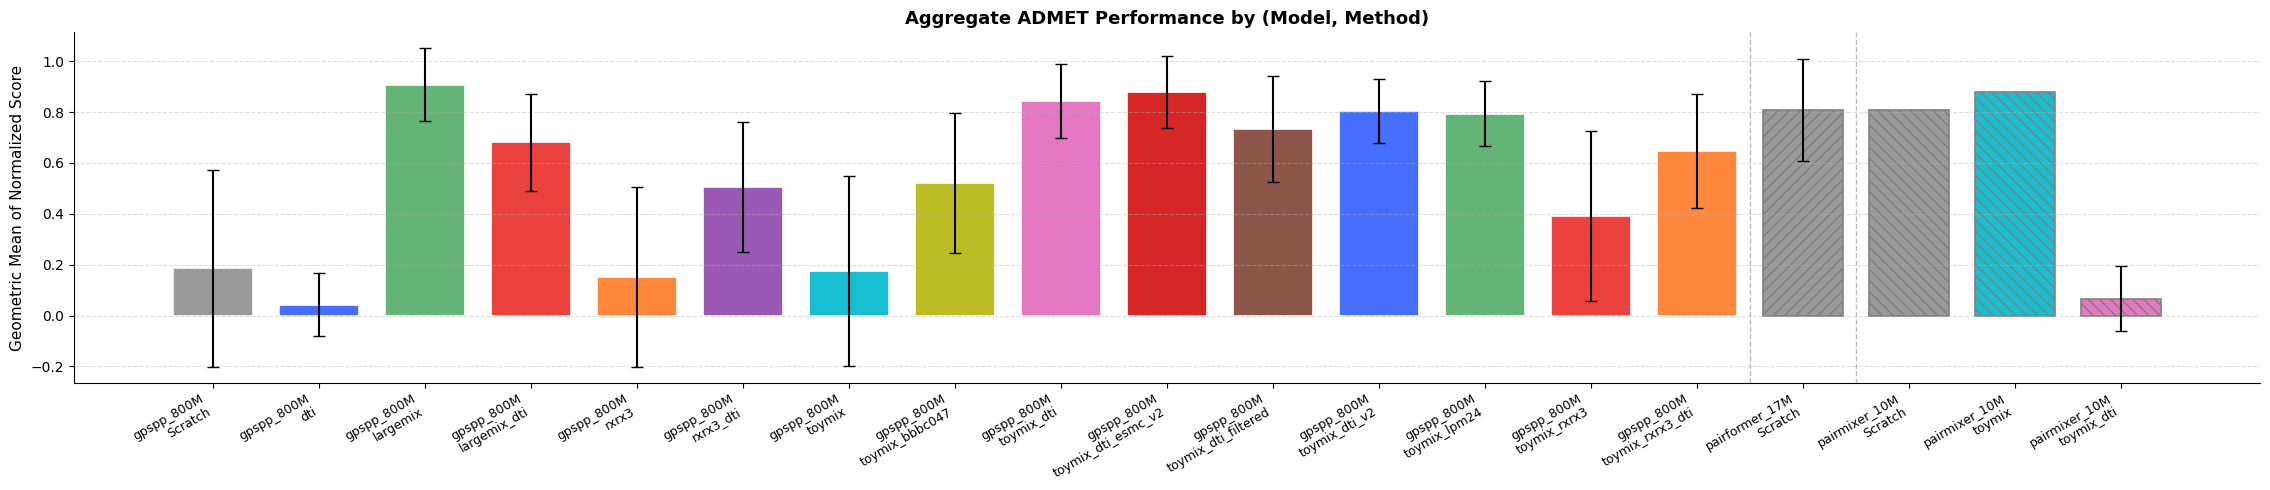

In [6]:
if len(agg_df) > 0 and agg_df['primary_metric'].notna().any():
    agg_df = agg_df.copy()

    # Create a combined label: "model / method"
    agg_df['model_method'] = agg_df['model_name'] + ' / ' + agg_df['method']

    # Normalize within each task: map metric to [0, 1] where 1 = best
    scores = []
    for task, group in agg_df.groupby('task'):
        direction = TASK_METRICS.get(task, (None, 'higher'))[1]
        vals = group['primary_metric'].astype(float)
        if direction == 'lower':
            vals = -vals
        vmin, vmax = vals.min(), vals.max()
        if vmax == vmin:
            norm = pd.Series(0.5, index=group.index)
        else:
            norm = (vals - vmin) / (vmax - vmin)
        scores.append(norm)
    agg_df['normalized_score'] = pd.concat(scores).astype(float)

    from scipy.stats import gmean
    EPSILON = 0.01  # floor to avoid log(0) in geomean
    def _geomean_agg(scores):
        clipped = np.clip(scores.values, EPSILON, None)
        return gmean(clipped)
    agg = agg_df.groupby(['model_name', 'method'])['normalized_score'].agg(
        mean=_geomean_agg, std='std', count='count'
    )

    # Sort: by model order, then Scratch first, then FT alphabetically
    def sort_key(idx):
        model, method = idx
        model_order = MODELS_TO_SHOW.index(model) if model in MODELS_TO_SHOW else 999
        if method == 'Scratch':
            return (model_order, 0, method)
        return (model_order, 1, method)
    agg = agg.loc[sorted(agg.index, key=sort_key)]

    # Build display labels
    labels = [f'{m}\n{meth}' for m, meth in agg.index]

    # Color palette: same method gets same color regardless of model;
    # different models get different hatching
    method_colors = METHOD_COLORS

    # Hatch by model family (architecture), not individual size
    _FAMILY_HATCHES = {'GPS++': '', 'Pairformer': '///', 'PairMixer': '\\\\\\'}
    model_hatches = {}
    for m in MODELS_TO_SHOW:
        fam = infer_model_family(m)
        model_hatches[m] = _FAMILY_HATCHES.get(fam, 'xx')

    fig, ax = plt.subplots(figsize=(max(10, len(agg) * 1.2), 5))
    x = np.arange(len(agg))
    for i, ((model, method), row) in enumerate(agg.iterrows()):
        color = method_colors.get(method, '#466eff')
        hatch = model_hatches.get(model, '')
        ax.bar(i, row['mean'], yerr=row['std'], color=color, hatch=hatch,
               edgecolor='white' if not hatch else 'grey',
               capsize=4, linewidth=1.2, width=0.75)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Geometric Mean of Normalized Score', fontsize=11)
    ax.set_title('Aggregate ADMET Performance by (Model, Method)', fontsize=13, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, axis='y', ls='--', alpha=0.4)

    # Add vertical separators between models
    prev_model = None
    for i, (model, _) in enumerate(agg.index):
        if prev_model is not None and model != prev_model:
            ax.axvline(x=i - 0.5, color='grey', linewidth=1, linestyle='--', alpha=0.5)
        prev_model = model

    plt.tight_layout()
    plt.show()
else:
    print("No ADMET results to aggregate.")


## 5. Per-task comparison: SOTA vs selected methods

5×6 grid where each row is an ADMET category (Absorption, Distribution, Metabolism, Excretion, Toxicity).
TDC SOTA shown as a thick black horizontal line with ±std shading. Our methods shown as colored bars.

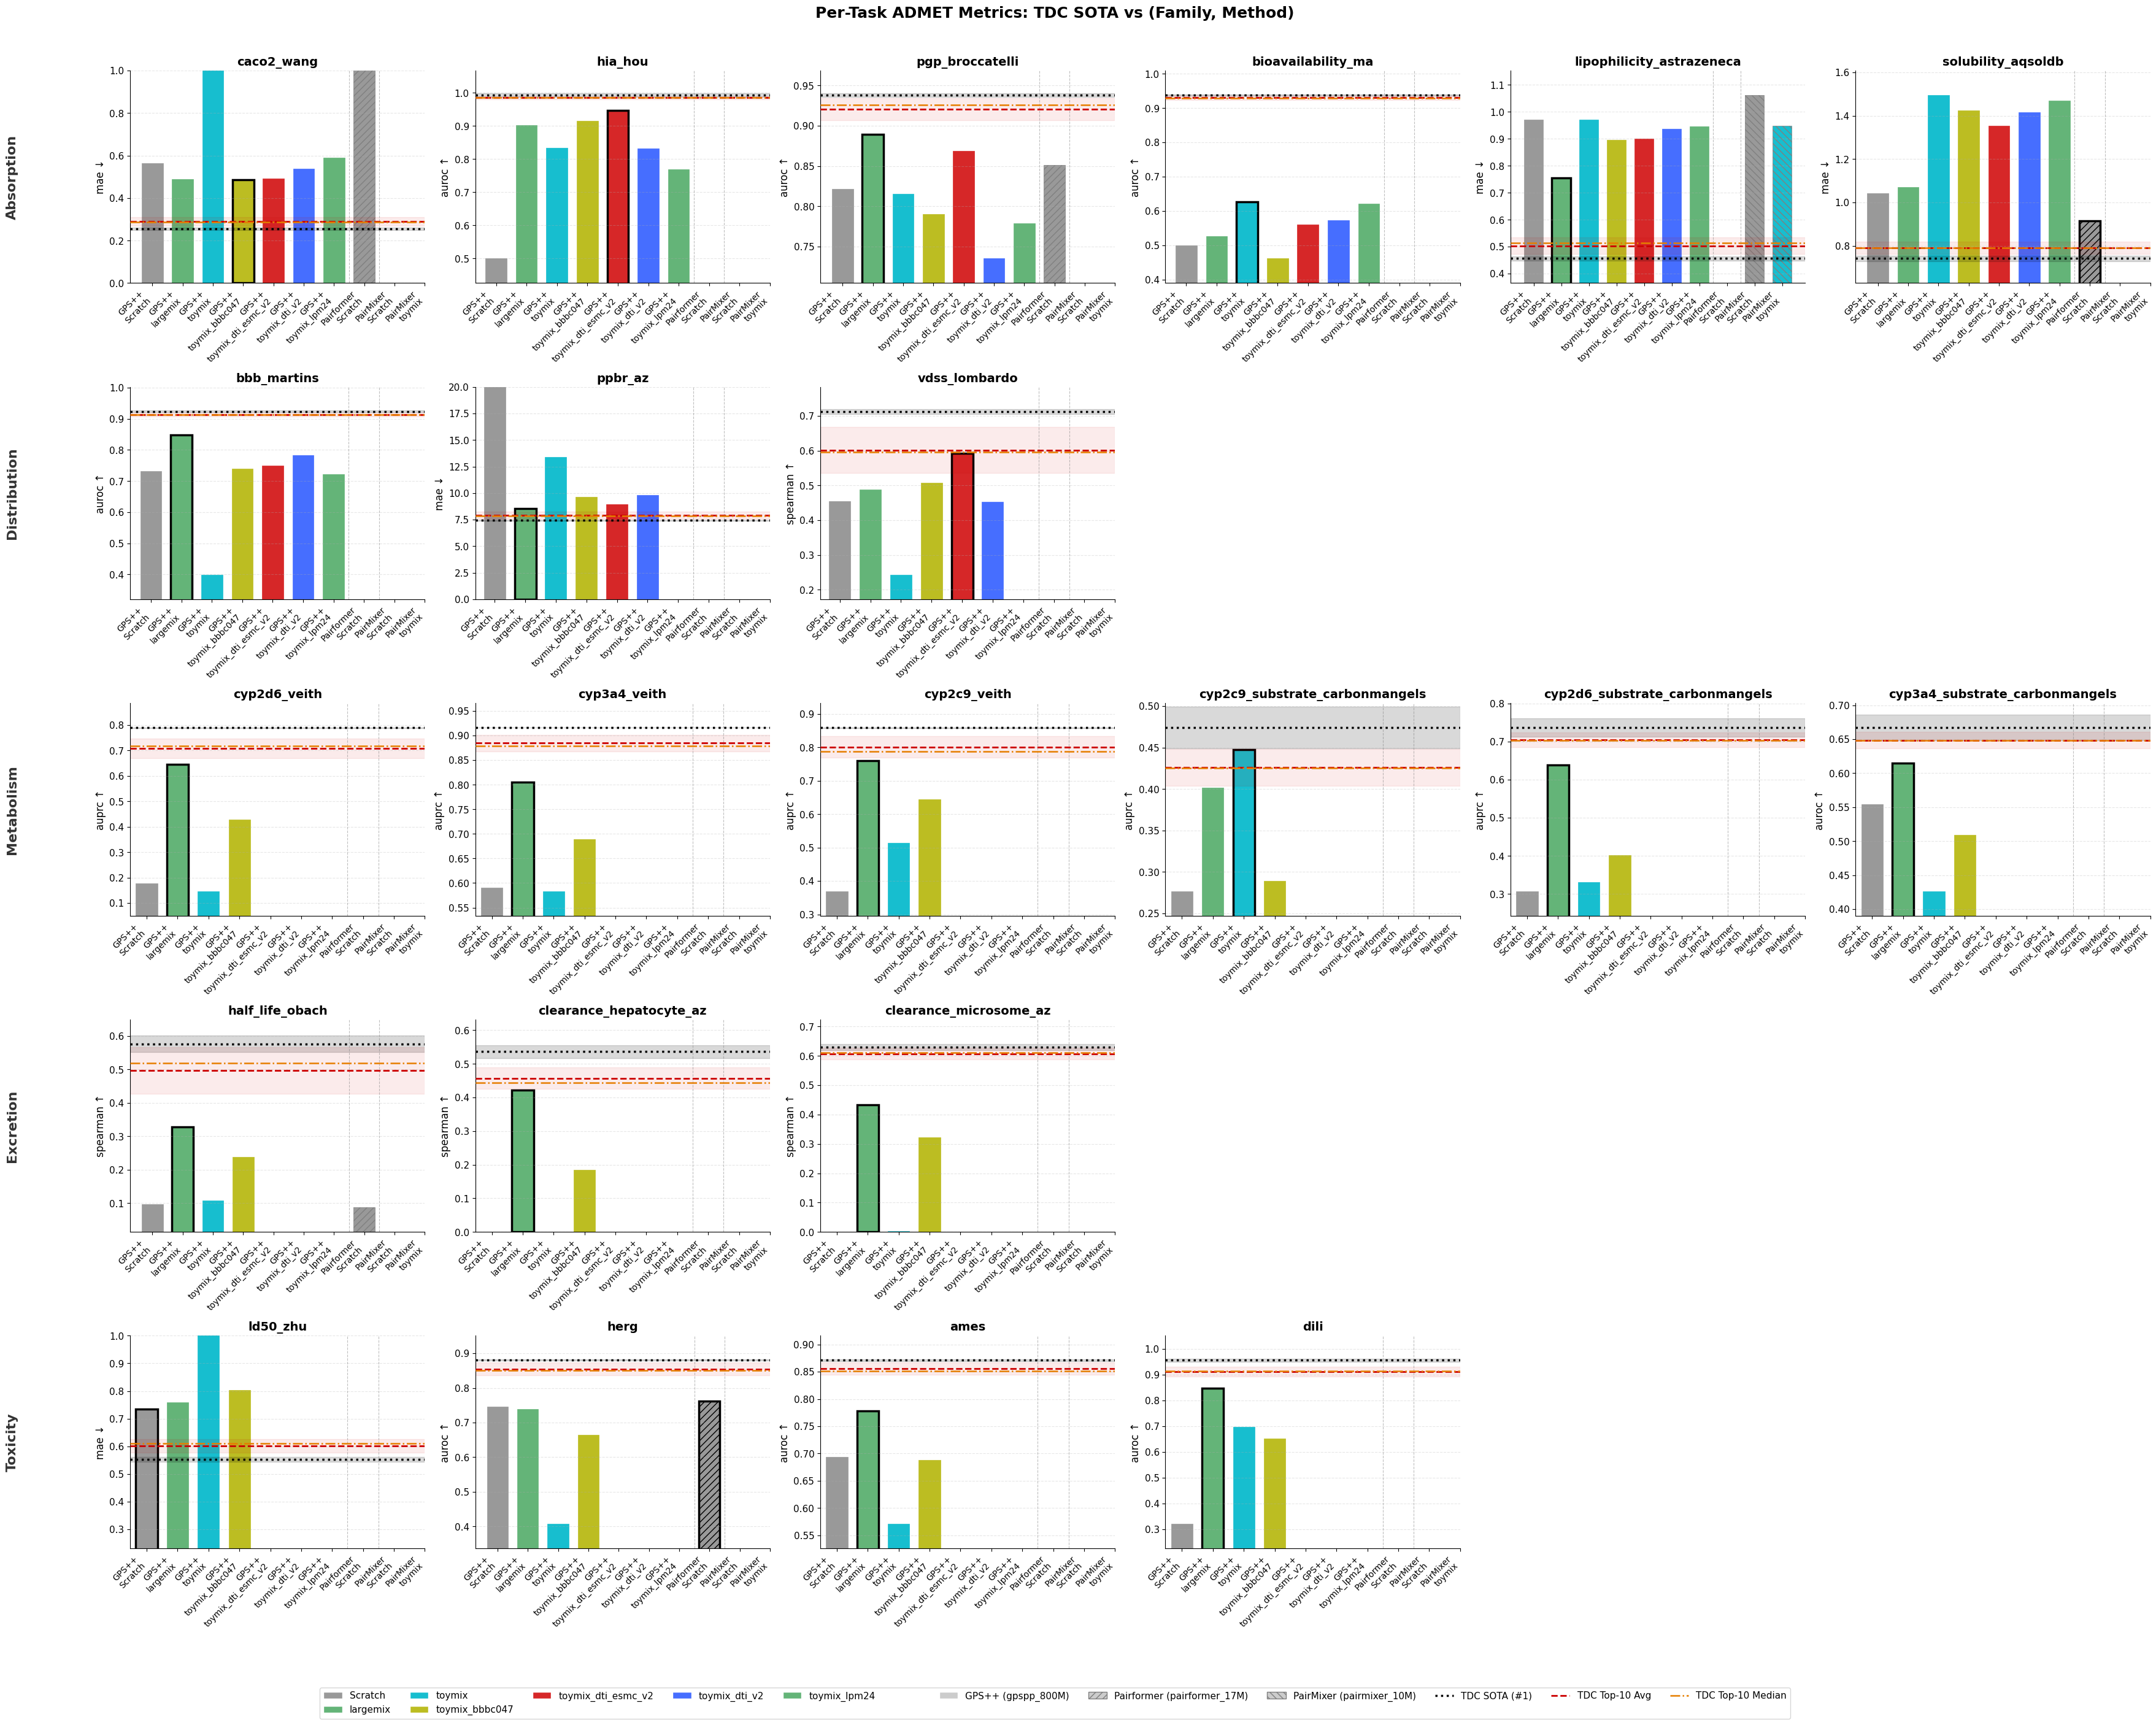


Pairs shown: 10
Default variants: {'GPS++': 'gpspp_800M', 'Pairformer': 'pairformer_17M', 'PairMixer': 'pairmixer_10M'}
TDC SOTA (#1): dotted black horizontal line with ±std shading
TDC Top-10 Avg: dashed red horizontal line with ±std shading
TDC Top-10 Median: dash-dot orange horizontal line
Error bars: ± std across runs for each (model, method) pair
Best across all (family, method): thick black border

  Win Count Summary: tasks where each method beats the baseline


Model / Method,Tasks,Beat Top-10 Avg,Beat Top-10 Median,Beat Scratch
GPS++ / Scratch,22,0,0,-
GPS++ / largemix,22,0,0,19
GPS++ / toymix,22,1,1,11
GPS++ / toymix_bbbc047,22,0,0,15
GPS++ / toymix_dti_esmc_v2,9,0,0,8
GPS++ / toymix_dti_v2,9,0,0,6
GPS++ / toymix_lpm24,7,0,0,4
Pairformer / Scratch,5,0,0,-
PairMixer / Scratch,1,0,0,-
PairMixer / toymix,1,0,0,1



Model / Method                      Tasks   vs Avg   vs Med  vs Scratch
----------------------------------------------------------------------
  GPS++ / Scratch                      22        0        0           -
  GPS++ / largemix                     22        0        0          19
  GPS++ / toymix                       22        1        1          11
  GPS++ / toymix_bbbc047               22        0        0          15
  GPS++ / toymix_dti_esmc_v2            9        0        0           8
  GPS++ / toymix_dti_v2                 9        0        0           6
  GPS++ / toymix_lpm24                  7        0        0           4
  Pairformer / Scratch                  5        0        0           -
  PairMixer / Scratch                   1        0        0           -
  PairMixer / toymix                    1        0        0           1


In [9]:
# === Config: select which methods to show ===
# SELECTED_METHODS = ['Scratch', 'toymix', 'toymix_dti']
# SELECTED_METHODS = ['Scratch', 'toymix', 'largemix', 'toymix_rxrx3', 'toymix_dti', 'toymix_dti_filtered', 'toymix_bbbc047', 'largemix_dti', 'toymix_dti_v2', 'toymix_dti_esmc_v2', 'toymix_lpm24']
SELECTED_METHODS = ['Scratch', 'toymix', 'largemix', 'toymix_bbbc047', 'toymix_dti_v2', 'toymix_dti_esmc_v2', 'toymix_lpm24']

# Per-task y-axis overrides: {task: (ymin, ymax)} — set either to None to auto-compute
TASK_YLIM_OVERRIDES = {
    'caco2_wang': (None, 1),
    'ppbr_az': (None, 20),
    'ld50_zhu': (None, 1),
}

# Uses DEFAULT_VARIANT (defined in cell 1) — one representative model per family.
# Legend is collapsed to family level.
SELECTED_MODELS = list(DEFAULT_VARIANT.values())

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

if len(admet_df) > 0 and admet_df['primary_metric'].notna().any():
    # Group by (task, model_name, method) — compute mean AND std
    task_model_method_stats = admet_df.groupby(['task', 'model_name', 'method'])['primary_metric'].agg(['mean', 'std', 'count'])
    task_model_method_means = task_model_method_stats['mean']
    task_model_method_stds = task_model_method_stats['std'].fillna(0)

    # Build the list of (model, method) pairs to plot
    all_available = sorted(admet_df[['model_name', 'method']].drop_duplicates().apply(tuple, axis=1))
    pairs_to_plot = [(m, meth) for m, meth in all_available if m in SELECTED_MODELS]
    if SELECTED_METHODS is not None:
        pairs_to_plot = [(m, meth) for m, meth in pairs_to_plot if meth in SELECTED_METHODS]

    # Sort: by family order (GPS++ -> Pairformer -> PairMixer), Scratch first within each model
    _FAMILY_ORDER = {'GPS++': 0, 'Pairformer': 1, 'PairMixer': 2}
    def pair_sort_key(pair):
        model, method = pair
        fam_order = _FAMILY_ORDER.get(infer_model_family(model), 999)
        return (fam_order, 0 if method == 'Scratch' else 1, method)
    pairs_to_plot = sorted(pairs_to_plot, key=pair_sort_key)

    # Short labels for x-axis: "family\nmethod"
    short_labels = [f'{infer_model_family(m)}\n{meth}' for m, meth in pairs_to_plot]

    n_bars = len(pairs_to_plot)

    # Color palette: same method = same color; family distinguished by hatch
    method_colors = METHOD_COLORS
    colors = [method_colors.get(meth, '#466eff') for _, meth in pairs_to_plot]
    hatches = [FAMILY_HATCHES.get(infer_model_family(m), '') for m, _ in pairs_to_plot]

    # Layout: 5 rows (one per ADMET category) x 6 cols
    CATEGORIES_ORDER = ['Absorption', 'Distribution', 'Metabolism', 'Excretion', 'Toxicity']
    CATEGORY_TASKS = {cat: [t for t in ADMET_TASK_ORDER if TASK_CATEGORY[t] == cat] for cat in CATEGORIES_ORDER}

    fig, axes = plt.subplots(5, 6, figsize=(max(36, n_bars * 2), 28))
    x_pos = np.arange(n_bars)

    # --- Track wins against TDC top-10 average ---
    wins_vs_top10 = {}  # (model, method) -> number of tasks beating top-10 avg
    for pair in pairs_to_plot:
        wins_vs_top10[pair] = 0
    total_comparable_tasks = 0

    for row_idx, cat in enumerate(CATEGORIES_ORDER):
        tasks_in_cat = CATEGORY_TASKS[cat]
        for col_idx in range(6):
            ax = axes[row_idx, col_idx]

            if col_idx >= len(tasks_in_cat):
                ax.set_visible(False)
                continue

            task = tasks_in_cat[col_idx]
            metric_name, direction = TASK_METRICS[task]
            arrow = '\u2191' if direction == 'higher' else '\u2193'

            # Collect mean and std for each (model, method) pair
            vals = []
            errs = []
            for model, method in pairs_to_plot:
                try:
                    vals.append(task_model_method_means.loc[(task, model, method)])
                except KeyError:
                    vals.append(np.nan)
                try:
                    errs.append(task_model_method_stds.loc[(task, model, method)])
                except KeyError:
                    errs.append(0)
            vals = np.array(vals, dtype=float)
            errs = np.array(errs, dtype=float)

            sota_mean = None
            if task in TDC_SOTA:
                sota_mean = TDC_SOTA[task][0]

            top10_mean = None
            top10_std = None
            if task in TDC_TOP10_AVG:
                top10_mean, top10_std = TDC_TOP10_AVG[task]

            # Count wins vs TDC top-10 average
            if top10_mean is not None:
                task_counted = False
                for idx_p, (v, pair) in enumerate(zip(vals, pairs_to_plot)):
                    if not np.isfinite(v):
                        continue
                    if not task_counted:
                        task_counted = True
                    beats = (direction == 'lower' and v <= top10_mean) or \
                            (direction == 'higher' and v >= top10_mean)
                    if beats:
                        wins_vs_top10[pair] += 1
                if task_counted:
                    total_comparable_tasks += 1

            # Find best among all pairs
            finite_mask = np.isfinite(vals)
            best_idx = None
            if any(finite_mask):
                if direction == 'lower':
                    best_idx = np.where(finite_mask, vals, np.inf).argmin()
                else:
                    best_idx = np.where(finite_mask, vals, -np.inf).argmax()

            # Plot bars with error bars
            for i, (v, e, c, h) in enumerate(zip(vals, errs, colors, hatches)):
                if np.isfinite(v):
                    err_val = e if np.isfinite(e) and e > 0 else None
                    if i == best_idx:
                        ax.bar(i, v, yerr=err_val, color=c, hatch=h,
                               edgecolor='black', linewidth=2.5, width=0.7,
                               capsize=3, error_kw={'linewidth': 1.2})
                    else:
                        ec = 'grey' if h else c
                        ax.bar(i, v, yerr=err_val, color=c, hatch=h,
                               edgecolor=ec, linewidth=0.5, width=0.7,
                               capsize=3, error_kw={'linewidth': 1.0, 'color': '#555'})

            # SOTA as dotted black horizontal line with +/-std shading
            if sota_mean is not None:
                _, sota_std, sota_method = TDC_SOTA[task]
                ax.axhline(y=sota_mean, color='black', linewidth=2.5, linestyle=':', zorder=5)
                ax.axhspan(sota_mean - sota_std, sota_mean + sota_std, alpha=0.15, color='black', zorder=1)

            # TDC top-10 average as dashed red line with +/-std shading
            if top10_mean is not None:
                ax.axhline(y=top10_mean, color='#cc0000', linewidth=2.0, linestyle='--', zorder=4)
                ax.axhspan(top10_mean - top10_std, top10_mean + top10_std,
                           alpha=0.08, color='#cc0000', zorder=1)

            # TDC top-10 median as dash-dot orange line
            top10_median = TDC_TOP10_MEDIAN.get(task)
            if top10_median is not None:
                ax.axhline(y=top10_median, color='#e67e00', linewidth=1.8, linestyle='-.', zorder=4)

            # Adjust y-axis limits
            all_finite = vals[np.isfinite(vals)].tolist()
            if sota_mean is not None:
                all_finite.append(sota_mean)
            if top10_mean is not None:
                all_finite.append(top10_mean)
            if top10_median is not None:
                all_finite.append(top10_median)
            if len(all_finite) >= 1:
                vmin, vmax = min(all_finite), max(all_finite)
                span = vmax - vmin if vmax > vmin else vmax * 0.1
                padding = span * 0.15
                ylo = max(0, vmin - padding)
                yhi = vmax + padding
                if task in TASK_YLIM_OVERRIDES:
                    override_lo, override_hi = TASK_YLIM_OVERRIDES[task]
                    if override_lo is not None:
                        ylo = override_lo
                    if override_hi is not None:
                        yhi = override_hi
                ax.set_ylim(ylo, yhi)

            ax.set_xticks(x_pos)
            ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=10)
            ax.set_title(f'{task}', fontsize=14, fontweight='bold')
            ax.set_ylabel(f'{metric_name} {arrow}', fontsize=12)
            ax.tick_params(axis='y', labelsize=11)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(True, axis='y', ls='--', alpha=0.3)

            # Vertical separator between families
            prev_family = None
            for i, (model, _) in enumerate(pairs_to_plot):
                fam = infer_model_family(model)
                if prev_family is not None and fam != prev_family:
                    ax.axvline(x=i - 0.5, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
                prev_family = fam

            if col_idx == 0:
                ax.annotate(cat, xy=(-0.4, 0.5), xycoords='axes fraction',
                            fontsize=16, fontweight='bold', color='#333',
                            ha='center', va='center', rotation=90)

    # Legend: pretrain dataset colors + family hatching + SOTA line + top-10 avg line
    legend_handles = []
    # Pretrain dataset colors
    seen_methods = []
    for _, meth in pairs_to_plot:
        if meth not in seen_methods:
            seen_methods.append(meth)
    for meth in seen_methods:
        legend_handles.append(Patch(facecolor=method_colors.get(meth, '#466eff'),
                                    edgecolor='white', label=meth))
    # Separator
    legend_handles.append(Patch(facecolor='none', edgecolor='none', label=''))
    # Family hatching (one entry per family, showing the selected variant)
    for fam in ['GPS++', 'Pairformer', 'PairMixer']:
        variant = DEFAULT_VARIANT.get(fam)
        if variant is None:
            continue
        h = FAMILY_HATCHES.get(fam, '')
        label = f'{fam} ({variant})'
        legend_handles.append(Patch(facecolor='#cccccc', hatch=h,
                                    edgecolor='grey' if h else 'white', label=label))
    legend_handles.append(Line2D([0], [0], color='black', linewidth=2.5, linestyle=':', label='TDC SOTA (#1)'))
    legend_handles.append(Line2D([0], [0], color='#cc0000', linewidth=2.0, linestyle='--', label='TDC Top-10 Avg'))
    legend_handles.append(Line2D([0], [0], color='#e67e00', linewidth=1.8, linestyle='-.', label='TDC Top-10 Median'))
    fig.legend(handles=legend_handles, loc='lower center', ncol=min(len(legend_handles), 12), fontsize=11, bbox_to_anchor=(0.5, -0.02), frameon=True)

    fig.suptitle('Per-Task ADMET Metrics: TDC SOTA vs (Family, Method)', fontsize=18, fontweight='bold')
    plt.tight_layout(rect=[0.03, 0.03, 1, 0.97])
    plt.show()

    print(f"\nPairs shown: {len(pairs_to_plot)}")
    print(f"Default variants: {DEFAULT_VARIANT}")
    print("TDC SOTA (#1): dotted black horizontal line with \u00b1std shading")
    print("TDC Top-10 Avg: dashed red horizontal line with \u00b1std shading")
    print("TDC Top-10 Median: dash-dot orange horizontal line")
    print("Error bars: \u00b1 std across runs for each (model, method) pair")
    print("Best across all (family, method): thick black border")

    # --- Comparison table: wins vs TDC top-10 avg, median, and Scratch ---
    if total_comparable_tasks > 0:
        # Collect Scratch values per task (average across all models)
        scratch_vals = {}
        for task in ADMET_TASK_ORDER:
            scratch_rows = admet_df[(admet_df['task'] == task) & (admet_df['method'] == 'Scratch')]
            if len(scratch_rows) > 0 and scratch_rows['primary_metric'].notna().any():
                scratch_vals[task] = scratch_rows['primary_metric'].mean()

        # Build comparison data for each (model, method) pair
        comp_rows = []
        for model, method in pairs_to_plot:
            fam = infer_model_family(model)
            label = f"{fam} / {method}"
            wins_avg = 0
            wins_med = 0
            wins_scratch = 0
            n_tasks = 0

            for task in ADMET_TASK_ORDER:
                try:
                    val = task_model_method_means.loc[(task, model, method)]
                except KeyError:
                    continue
                if not np.isfinite(val):
                    continue

                direction = TASK_METRICS.get(task, (None, 'higher'))[1]
                n_tasks += 1

                # vs TDC top-10 average
                if task in TDC_TOP10_AVG:
                    t10_mean, _ = TDC_TOP10_AVG[task]
                    if (direction == 'lower' and val <= t10_mean) or \
                       (direction == 'higher' and val >= t10_mean):
                        wins_avg += 1

                # vs TDC top-10 median
                if task in TDC_TOP10_MEDIAN:
                    t10_med = TDC_TOP10_MEDIAN[task]
                    if (direction == 'lower' and val <= t10_med) or \
                       (direction == 'higher' and val >= t10_med):
                        wins_med += 1

                # vs Scratch (same model)
                if task in scratch_vals:
                    sv = scratch_vals[task]
                    # For scratch comparison: check if this method is better than scratch
                    if method != 'Scratch':
                        if (direction == 'lower' and val < sv) or \
                           (direction == 'higher' and val > sv):
                            wins_scratch += 1

            comp_rows.append({
                'label': label,
                'model': model,
                'method': method,
                'n_tasks': n_tasks,
                'vs_top10_avg': wins_avg,
                'vs_top10_med': wins_med,
                'vs_scratch': wins_scratch if method != 'Scratch' else '-',
            })

        # Display as styled DataFrame table
        comp_df = pd.DataFrame(comp_rows)
        comp_df = comp_df.rename(columns={
            'label': 'Model / Method',
            'n_tasks': 'Tasks',
            'vs_top10_avg': 'Beat Top-10 Avg',
            'vs_top10_med': 'Beat Top-10 Median',
            'vs_scratch': 'Beat Scratch',
        })
        comp_df = comp_df[['Model / Method', 'Tasks', 'Beat Top-10 Avg', 'Beat Top-10 Median', 'Beat Scratch']]

        print(f"\n{'='*80}")
        print("  Win Count Summary: tasks where each method beats the baseline")
        print(f"{'='*80}")

        styled_comp = (
            comp_df.style
            .set_caption('Tasks beating TDC Top-10 Average / Median / Scratch baseline')
            .set_table_styles([
                {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
                {'selector': 'td', 'props': [('text-align', 'center')]},
                {'selector': 'td:first-child', 'props': [('text-align', 'left')]},
            ])
            .hide(axis='index')
        )
        display(styled_comp)

        # Also print text version
        print(f"\n{'Model / Method':35s} {'Tasks':>5s}  {'vs Avg':>7s}  {'vs Med':>7s}  {'vs Scratch':>10s}")
        print("-" * 70)
        for _, row in comp_df.iterrows():
            print(f"  {row['Model / Method']:33s} {row['Tasks']:>5}  {row['Beat Top-10 Avg']:>7}  {row['Beat Top-10 Median']:>7}  {str(row['Beat Scratch']):>10}")
else:
    print("No ADMET results to plot.")


## 6. Transfer Efficiency

How much downstream ADMET improvement do we get per hour of pretraining?
Compares `(ADMET_score - Scratch_score) / pretrain_GPU_hours` across pretrain datasets.

Transfer Efficiency: mean normalized improvement per GPU-hour
Model                Method                     GPU-hrs  Avg Delta Eff (delta/hr)  Tasks
------------------------------------------------------------------------------------------
gpspp_800M           toymix_lpm24                   2.0     0.1459         0.0729      7
gpspp_800M           toymix_dti                     7.4     0.4108         0.0555     22
gpspp_800M           toymix_rxrx3                   3.7     0.1499         0.0405     22
gpspp_800M           toymix_dti_esmc_v2             7.4     0.2834         0.0383      9
gpspp_800M           toymix_dti_v2                  7.4     0.2053         0.0277      9
gpspp_800M           toymix_bbbc047                10.1     0.2250         0.0223     22
gpspp_800M           toymix_dti_filtered           15.0     0.3223         0.0215     22
gpspp_800M           largemix                     160.5     0.4778         0.0030     22
gpspp_800M           largemix_dti             

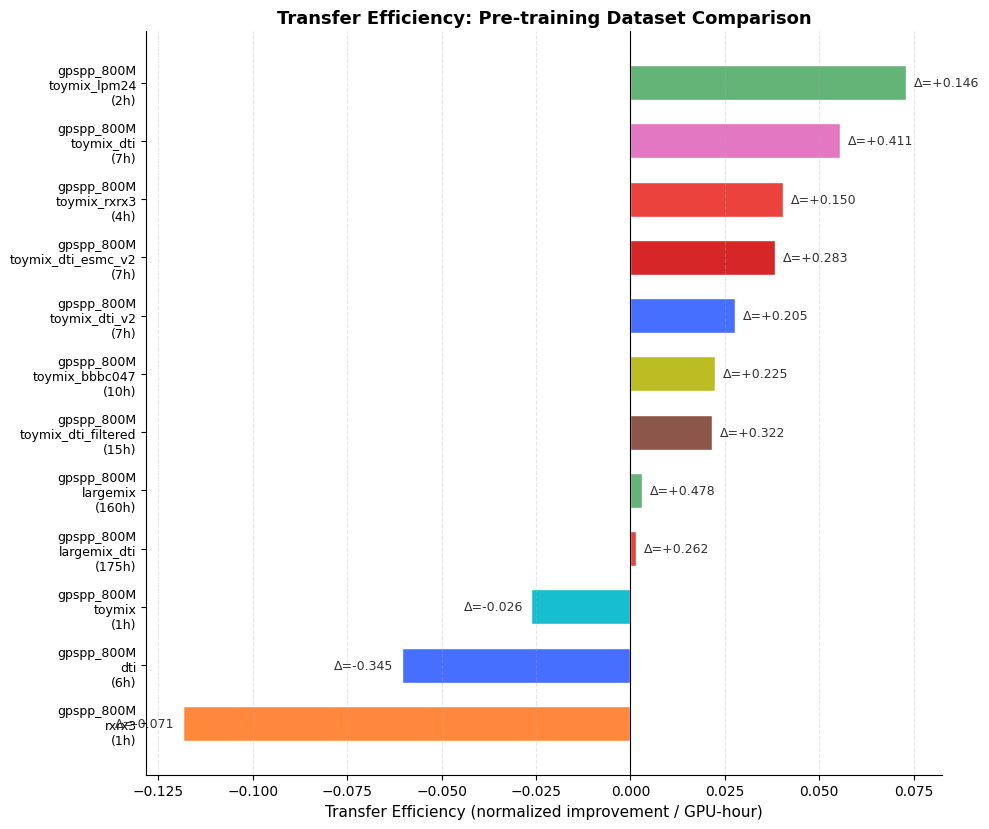

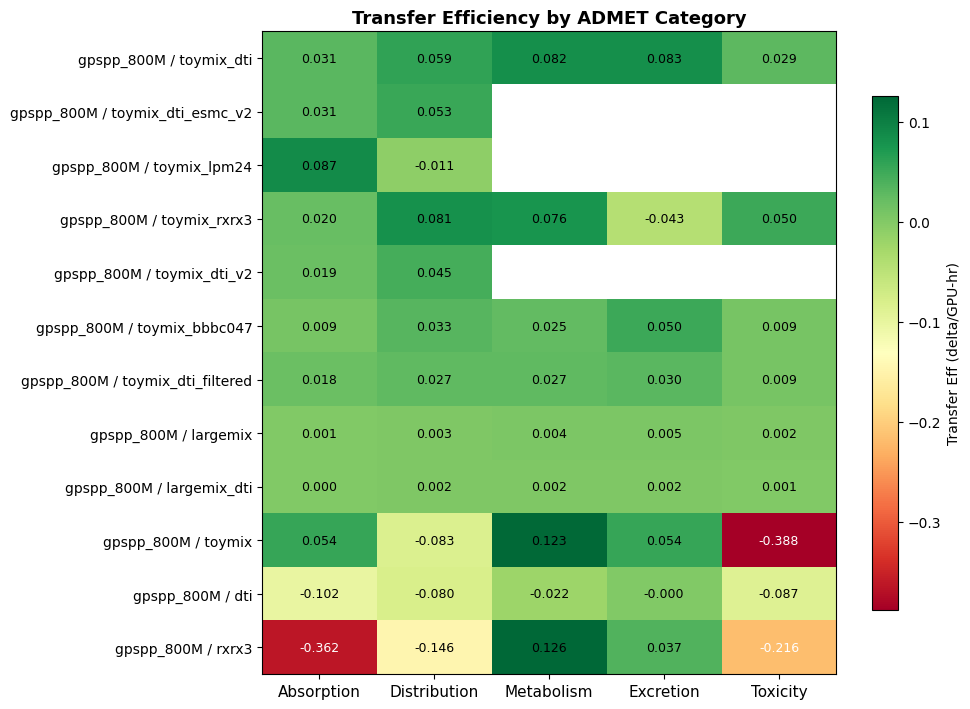

In [8]:
# ── Pretrain GPU-hours lookup ─────���────────────────────────────────────────────
# Measured from output directory timestamps (config -> test_results.yaml elapsed).
# Update these as you run new pretraining jobs.
#   Key: pretrain_type (must match parse_pretrain_dataset output)
#   Value: GPU-hours for one full pretraining run
#
# These are per-model because larger models take longer on the same dataset.
PRETRAIN_GPU_HOURS = {
    # (model_name, pretrain_type) -> GPU-hours
    # gpspp_800M
    ('gpspp_800M', 'toymix'):              1.0,
    ('gpspp_800M', 'toymix_dti'):           7.4,
    ('gpspp_800M', 'toymix_rxrx3'):         3.7,
    ('gpspp_800M', 'toymix_dti_filtered'):  15.0,
    ('gpspp_800M', 'toymix_bbbc047'):       10.1,
    ('gpspp_800M', 'rxrx3'):                0.6,
    ('gpspp_800M', 'dti'):                  5.7,
    ('gpspp_800M', 'largemix'):             160.5,
    ('gpspp_800M', 'largemix_dti'):         175.0,  # estimated: largemix + dti overhead
    ('gpspp_800M', 'largemix_rxrx3'):       170.0,  # estimated: largemix + rxrx3 overhead
    ('gpspp_800M', 'toymix_dti_v2'):        7.4,   # similar to toymix_dti (same structure, ESM2 embeddings)
    ('gpspp_800M', 'toymix_dti_esmc_v2'):   7.4,   # similar to toymix_dti (same structure, ESMC embeddings)
    ('gpspp_800M', 'toymix_lpm24'):         2.0,   # estimated: toymix + LPM24 auxiliary task
    # pairformer_boltz
    ('pairformer_boltz', 'toymix'):          52.4,
    ('pairformer_boltz', 'rxrx3'):            4.9,
    ('pairformer_boltz', 'dti'):              8.0,  # estimated
    ('pairformer_boltz', 'toymix_dti_filtered'): 60.0,  # estimated
    # pairmixer_boltz (estimated from speed benchmark: ~1.75x faster than pairformer)
    ('pairmixer_boltz', 'toymix'):           30.0,
}

if len(admet_df) > 0 and admet_df['primary_metric'].notna().any():
    # Recompute normalized scores (same logic as Section 4)
    te_df = admet_df.copy()
    scores = []
    for task, group in te_df.groupby('task'):
        direction = TASK_METRICS.get(task, (None, 'higher'))[1]
        vals = group['primary_metric'].astype(float)
        if direction == 'lower':
            vals = -vals
        vmin, vmax = vals.min(), vals.max()
        if vmax == vmin:
            norm = pd.Series(0.5, index=group.index)
        else:
            norm = (vals - vmin) / (vmax - vmin)
        scores.append(norm)
    te_df['normalized_score'] = pd.concat(scores).astype(float)

    # Get scratch baseline score per (model, task)
    scratch_scores = (
        te_df[te_df['method'] == 'Scratch']
        .groupby(['model_name', 'task'])['normalized_score']
        .mean()
    )

    # Compute per-(model, method, task) improvement over scratch
    records = []
    for (model, method), group in te_df.groupby(['model_name', 'method']):
        if method == 'Scratch':
            continue
        pretrain_type = group['pretrain_type'].iloc[0]
        gpu_hours = PRETRAIN_GPU_HOURS.get((model, pretrain_type))
        if gpu_hours is None:
            continue
        for task, task_group in group.groupby('task'):
            method_score = task_group['normalized_score'].mean()
            scratch_key = (model, task)
            if scratch_key not in scratch_scores.index:
                continue
            scratch_score = scratch_scores[scratch_key]
            delta = method_score - scratch_score
            records.append({
                'model_name': model,
                'method': method,
                'pretrain_type': pretrain_type,
                'task': task,
                'gpu_hours': gpu_hours,
                'delta': delta,
                'transfer_eff': delta / gpu_hours,
            })

    te_records = pd.DataFrame(records)

    if len(te_records) > 0:
        # ── Table: mean transfer efficiency per (model, method) ──
        te_agg = te_records.groupby(['model_name', 'method', 'gpu_hours']).agg(
            mean_delta=('delta', 'mean'),
            mean_te=('transfer_eff', 'mean'),
            n_tasks=('task', 'nunique'),
        ).reset_index().sort_values('mean_te', ascending=False)

        print('Transfer Efficiency: mean normalized improvement per GPU-hour')
        print('=' * 90)
        print(f'{"Model":20s} {"Method":25s} {"GPU-hrs":>8s} {"Avg Delta":>10s} {"Eff (delta/hr)":>14s} {"Tasks":>6s}')
        print('-' * 90)
        for _, row in te_agg.iterrows():
            print(f'{row["model_name"]:20s} {row["method"]:25s} {row["gpu_hours"]:8.1f} '
                  f'{row["mean_delta"]:10.4f} {row["mean_te"]:14.4f} {row["n_tasks"]:6d}')
        print()

        # ── Bar chart ──
        te_agg = te_agg.sort_values('mean_te', ascending=True)  # horizontal bars, best on top
        labels = [f'{r["model_name"]}\n{r["method"]}\n({r["gpu_hours"]:.0f}h)' for _, r in te_agg.iterrows()]
        colors = [METHOD_COLORS.get(r['method'], '#466eff') for _, r in te_agg.iterrows()]

        fig, ax = plt.subplots(figsize=(10, max(4, len(te_agg) * 0.7)))
        y_pos = np.arange(len(te_agg))
        bars = ax.barh(y_pos, te_agg['mean_te'].values, color=colors, edgecolor='white', height=0.6)

        # Annotate bars with delta values
        for i, (_, row) in enumerate(te_agg.iterrows()):
            te_val = row['mean_te']
            delta_val = row['mean_delta']
            x_pos = te_val + (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.01 if te_val >= 0 else te_val - (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.01
            ha = 'left' if te_val >= 0 else 'right'
            ax.text(x_pos, i, f'\u0394={delta_val:+.3f}', va='center', ha=ha, fontsize=9, color='#333')

        ax.set_yticks(y_pos)
        ax.set_yticklabels(labels, fontsize=9)
        ax.set_xlabel('Transfer Efficiency (normalized improvement / GPU-hour)', fontsize=11)
        ax.set_title('Transfer Efficiency: Pre-training Dataset Comparison', fontsize=13, fontweight='bold')
        ax.axvline(x=0, color='black', linewidth=0.8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, axis='x', ls='--', alpha=0.3)
        plt.tight_layout()
        plt.show()

        # ── Per-category transfer efficiency breakdown ──
        te_records['category'] = te_records['task'].map(TASK_CATEGORY)
        cat_te = te_records.groupby(['model_name', 'method', 'category']).agg(
            mean_te=('transfer_eff', 'mean'),
            mean_delta=('delta', 'mean'),
        ).reset_index()

        # Heatmap: rows = (model, method), cols = ADMET categories
        cat_pivot = cat_te.pivot_table(
            index=['model_name', 'method'], columns='category', values='mean_te'
        )
        cat_pivot = cat_pivot[[c for c in ['Absorption', 'Distribution', 'Metabolism', 'Excretion', 'Toxicity']
                              if c in cat_pivot.columns]]
        # Sort by overall mean TE
        cat_pivot['_mean'] = cat_pivot.mean(axis=1)
        cat_pivot = cat_pivot.sort_values('_mean', ascending=False)
        cat_pivot = cat_pivot.drop(columns='_mean')

        fig, ax = plt.subplots(figsize=(10, max(3, len(cat_pivot) * 0.6)))
        im = ax.imshow(cat_pivot.values, cmap='RdYlGn', aspect='auto')
        ax.set_xticks(range(len(cat_pivot.columns)))
        ax.set_xticklabels(cat_pivot.columns, fontsize=11)
        ax.set_yticks(range(len(cat_pivot)))
        ylabels = [f'{m} / {meth}' for m, meth in cat_pivot.index]
        ax.set_yticklabels(ylabels, fontsize=10)

        # Annotate cells
        for i in range(len(cat_pivot)):
            for j in range(len(cat_pivot.columns)):
                val = cat_pivot.iloc[i, j]
                if pd.notna(val):
                    ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9,
                            color='white' if abs(val) > 0.5 * max(abs(cat_pivot.max().max()), abs(cat_pivot.min().min())) else 'black')

        plt.colorbar(im, ax=ax, label='Transfer Eff (delta/GPU-hr)', shrink=0.8)
        ax.set_title('Transfer Efficiency by ADMET Category', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print('No transfer efficiency data: no methods with known GPU-hours and scratch baselines.')
else:
    print('No ADMET results to compute transfer efficiency.')